# Kurinda Notebook 03: Model Training

## Spatial Generalization Classifier for Chronic Stunting Risk

**Problem framing.** DHS measured stunting in 500 sample clusters in 2019-20, which map to 320 of Rwanda's 422 administrative sectors. The remaining 102 sectors have no DHS measurement. This notebook trains a classifier that learns the relationship between environmental/economic conditions and chronic stunting on the 320 labeled sectors, then produces risk scores for the 102 unlabeled sectors the **operational deliverable** for CHW prioritization.

**Why spatial generalization, not temporal forecasting.** DHS provides one stunting measurement per sector. A genuine temporal forecaster would require a second time point to learn how stunting *changes*, which isn't available until DHS 2024-25 microdata is released. The proposal's "3–6 month lead time" is realized through **lag features** in notebook 02 — the model uses signals from t-1, t-3, t-6 months to score current risk.

**Architecture.**
- Target: binary `high_risk = (dhs_stunting_rate >= 30)` — WHO threshold for "very high public health significance"
- N: 320 labeled sectors (after aggregation), with 102 unlabeled held out for inference
- Features: ~50 temporal summaries (means, stds, season splits, trends, anomaly statistics, extreme-month counts) computed per sector from 2022-2025 monthly data
- Validation: stratified 70/15/15 split + leave-one-province-out CV robustness check
- Model: LightGBM with strong regularization for the small-N regime

In [1]:
# Setup — imports, paths, seed
from pathlib import Path
import numpy as np
import pandas as pd

# Reproducibility seed used everywhere a random choice is made
SEED = 42
np.random.seed(SEED)

# Load the engineered master dataset from notebook 02
FEATURES_PATH = Path("../../data/processed/master_sector_month_features.parquet")
df = pd.read_parquet(FEATURES_PATH)

# Sanity check — must match notebook 02's final shape
print(f"Loaded master features: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Sectors: {df['GID_3'].nunique():,}")
print(f"Months: {df.groupby('GID_3').size().iloc[0]} per sector (expected 72)")
print(f"Year range: {df['year'].min()}-{df['year'].max()}")
print(f"\nLabeled sectors (have dhs_stunting_rate): "
      f"{df[df['dhs_stunting_rate'].notna()]['GID_3'].nunique():,}")
print(f"Unlabeled sectors (NaN dhs_stunting_rate): "
      f"{df[df['dhs_stunting_rate'].isna()]['GID_3'].nunique():,}")

Loaded master features: 30,384 rows × 50 cols
Sectors: 422
Months: 72 per sector (expected 72)
Year range: 2020-2025

Labeled sectors (have dhs_stunting_rate): 320
Unlabeled sectors (NaN dhs_stunting_rate): 102


## 1. Define the target — WHO 30% threshold

The DHS stunting rate is continuous (0–100%). We binarize at the WHO threshold of 30%, which the WHO classifies as **"very high public health significance"**. This gives an internationally defensible cutoff with naturally balanced classes (Rwanda's national mean is 33%, so the split is roughly 50/50 among labeled sectors).

The target is **sector-level**: every row of a given sector inherits the same binary label, since `dhs_stunting_rate` was broadcast across all 72 months in notebook 02. We materialize the binary label here at row level for visibility, then collapse to one label per sector during aggregation.

In [2]:
# Apply WHO 30% threshold to define binary high-risk target
WHO_THRESHOLD = 30.0

# Target is NaN for unlabeled sectors (102 sectors), 0 or 1 for labeled (320)
df["target_high_risk"] = np.where(
    df["dhs_stunting_rate"].notna(),
    (df["dhs_stunting_rate"] >= WHO_THRESHOLD).astype(int),
    np.nan,
)

# Sector-level class balance among labeled sectors (one label per sector,
# so checking unique combinations is equivalent to checking sectors)
sector_labels = (
    df[df["dhs_stunting_rate"].notna()]
    .groupby("GID_3")["target_high_risk"]
    .first()
)

print(f"Labeled sectors: {len(sector_labels):,}")
print(f"  High-risk (>= 30%):  {int((sector_labels == 1).sum()):>3d} "
      f"({100*(sector_labels == 1).mean():.1f}%)")
print(f"  Low-risk  (<  30%):  {int((sector_labels == 0).sum()):>3d} "
      f"({100*(sector_labels == 0).mean():.1f}%)")
print(f"\nUnlabeled sectors (inference set): "
      f"{df[df['dhs_stunting_rate'].isna()]['GID_3'].nunique():,}")

Labeled sectors: 320
  High-risk (>= 30%):  176 (55.0%)
  Low-risk  (<  30%):  144 (45.0%)

Unlabeled sectors (inference set): 102


## 2. Aggregate sector-month → sector-level features

We collapse the 30,384-row sector-month panel into one row per sector (422 rows) by computing **temporal summaries** of each time-varying signal. This preserves the *shape* of each sector's time series (volatility, seasonality, trend, extreme events) without inflating the row count and overstating statistical power.

### 2a. Filter to 2022-2025 (anomaly-defined window)

Years 2020-2021 have NaN anomaly features (the leak-free expanding baseline doesn't exist for the panel's first two years). We restrict aggregation to **2022-2025 = 4 years = 48 months per sector**. The 102 unlabeled sectors are kept in the aggregation — we'll predict their risk in the inference step.

In [3]:
# Restrict to the anomaly-defined window
df_window = df[df["year"] >= 2022].copy()

# Verify: every sector should have exactly 48 months in the window
months_per_sector = df_window.groupby("GID_3").size()
assert (months_per_sector == 48).all(), (
    f"Some sectors lost months: min={months_per_sector.min()}, max={months_per_sector.max()}"
)

print(f"Window shape: {df_window.shape[0]:,} rows ({df_window['GID_3'].nunique()} sectors × "
      f"{months_per_sector.iloc[0]} months)")
print(f"Year range: {df_window['year'].min()}-{df_window['year'].max()}")

# Define Rwanda's wet/dry season month sets (used in season-split features below)
DRY_MONTHS = [1, 2, 6, 7, 8, 9]    # Urugaryi (Jan-Feb) + Icyi (Jun-Sep)
WET_MONTHS = [3, 4, 5, 10, 11, 12] # Itumba (Mar-May) + Umuhindo (Oct-Dec)
print(f"\nRwanda seasonal split: dry months = {DRY_MONTHS}, wet months = {WET_MONTHS}")

Window shape: 20,256 rows (422 sectors × 48 months)
Year range: 2022-2025

Rwanda seasonal split: dry months = [1, 2, 6, 7, 8, 9], wet months = [3, 4, 5, 10, 11, 12]


### 2b. Helper functions — temporal summary primitives

Every feature family uses the same set of summary primitives. We define them once.

In [4]:
def linear_trend(series: pd.Series) -> float:
    """Slope of a linear regression on the original time index.
    Returns NaN if fewer than 3 valid observations exist."""
    mask = series.notna()
    if mask.sum() < 3:
        return np.nan
    x = np.arange(len(series))[mask.values]
    y = series.values[mask.values]
    return float(np.polyfit(x, y, 1)[0])

def coefficient_of_variation(series: pd.Series) -> float:
    """Std / mean — scale-invariant volatility measure for prices.
    Returns NaN if mean is zero or series has fewer than 2 obs."""
    s = series.dropna()
    if len(s) < 2:
        return np.nan
    m = s.mean()
    if m == 0:
        return np.nan
    return float(s.std() / m)

def count_extreme(series: pd.Series, threshold: float, direction: str = "above") -> int:
    """Count months where the (anomaly) value exceeds a threshold in the given direction.
    direction='above' counts s > threshold; direction='below' counts s < threshold.
    NaN values do not contribute to either side."""
    s = series.dropna()
    if direction == "above":
        return int((s > threshold).sum())
    return int((s < threshold).sum())

# Quick smoke test on the helpers
_test = pd.Series([1.0, 2.0, 3.0, np.nan, 5.0])
print(f"linear_trend([1,2,3,NaN,5]) = {linear_trend(_test):.4f}  (expected 1.0)")
print(f"coefficient_of_variation([1,2,3,NaN,5]) = {coefficient_of_variation(_test):.4f}")
print(f"count_extreme([1,2,3,NaN,5], threshold=2, 'above') = "
      f"{count_extreme(_test, 2, 'above')}  (expected 2: values 3 and 5)")

linear_trend([1,2,3,NaN,5]) = 1.0000  (expected 1.0)
coefficient_of_variation([1,2,3,NaN,5]) = 0.6210
count_extreme([1,2,3,NaN,5], threshold=2, 'above') = 2  (expected 2: values 3 and 5)


### 2c. Climate temporal summaries — rainfall and NDVI

For each sector, we compute 9 rainfall features and 8 NDVI features:

| Feature pattern | What it captures |
|---|---|
| `*_mean`, `*_std` | Overall level and volatility |
| `*_dry_mean`, `*_wet_mean` | Seasonal split (Rwanda's bimodal climate) |
| `*_season_diff` | Strength of seasonality (wet − dry) |
| `*_trend` | Slope over 48 months (drying/greening) |
| `*_anomaly_p95`, `*_anomaly_p5` | Tail extremes of anomaly distribution |
| `n_extreme_*_months` | Count of months crossing ±1σ thresholds |

In [5]:
# Climate temporal summaries — rainfall and NDVI
records = []
for sector, g in df_window.groupby("GID_3", sort=False):
    rec = {"GID_3": sector}

    # ---- Rainfall (9 features) ----
    rain = g["rainfall_mm"]
    rain_anom = g["rainfall_mm_anomaly"]
    rec["rainfall_mean"]            = rain.mean()
    rec["rainfall_std"]             = rain.std()
    rec["rainfall_dry_mean"]        = rain[g["month"].isin(DRY_MONTHS)].mean()
    rec["rainfall_wet_mean"]        = rain[g["month"].isin(WET_MONTHS)].mean()
    rec["rainfall_season_diff"]     = rec["rainfall_wet_mean"] - rec["rainfall_dry_mean"]
    rec["rainfall_trend"]           = linear_trend(rain)
    rec["rainfall_anomaly_p95"]     = rain_anom.quantile(0.95)
    rec["rainfall_anomaly_p5"]      = rain_anom.quantile(0.05)
    rec["n_extreme_wet_months"]     = count_extreme(rain_anom, 1.0, "above")

    # ---- NDVI (8 features) ----
    ndvi = g["ndvi"]
    ndvi_anom = g["ndvi_anomaly"]
    rec["ndvi_mean"]                = ndvi.mean()
    rec["ndvi_std"]                 = ndvi.std()
    rec["ndvi_dry_mean"]            = ndvi[g["month"].isin(DRY_MONTHS)].mean()
    rec["ndvi_wet_mean"]            = ndvi[g["month"].isin(WET_MONTHS)].mean()
    rec["ndvi_season_diff"]         = rec["ndvi_wet_mean"] - rec["ndvi_dry_mean"]
    rec["ndvi_trend"]               = linear_trend(ndvi)
    rec["ndvi_anomaly_p5"]          = ndvi_anom.quantile(0.05)
    rec["n_drought_months"]         = count_extreme(ndvi_anom, -1.0, "below")

    records.append(rec)

climate_features = pd.DataFrame(records).set_index("GID_3")
print(f"Climate features: {climate_features.shape[0]} sectors × {climate_features.shape[1]} features")
print(f"\nSample (first 3 sectors):")
print(climate_features.head(3).round(3).to_string())

Climate features: 422 sectors × 17 features

Sample (first 3 sectors):
              rainfall_mean  rainfall_std  rainfall_dry_mean  rainfall_wet_mean  rainfall_season_diff  rainfall_trend  rainfall_anomaly_p95  rainfall_anomaly_p5  n_extreme_wet_months  ndvi_mean  ndvi_std  ndvi_dry_mean  ndvi_wet_mean  ndvi_season_diff  ndvi_trend  ndvi_anomaly_p5  n_drought_months
GID_3                                                                                                                                                                                                                                                                                                     
RWA.1.1.10_1        100.957        65.893             58.260            143.654                85.394          -0.159                 3.485               -2.013                    10      0.598     0.061          0.563          0.634             0.071       0.001           -0.696                 0
RWA.1.1.11_1        101.081     

### 2d. Price temporal summaries

For each of the 6 staple commodities, compute three features:
- `mean` — overall average price (RWF)
- `cv` — coefficient of variation (std/mean) as a scale-invariant volatility measure
- `trend` — slope over 48 months (rising/falling prices)

That's 6 commodities × 3 stats = 18 price features per sector.

In [6]:
# Price temporal summaries
PRICE_COMMODITIES = ["beans_dry", "cassava_flour", "maize", "maize_flour",
                     "potatoes_irish", "sorghum"]

records = []
for sector, g in df_window.groupby("GID_3", sort=False):
    rec = {"GID_3": sector}
    for c in PRICE_COMMODITIES:
        col = f"price_{c}"
        rec[f"{c}_price_mean"]  = g[col].mean()
        rec[f"{c}_price_cv"]    = coefficient_of_variation(g[col])
        rec[f"{c}_price_trend"] = linear_trend(g[col])
    records.append(rec)

price_features = pd.DataFrame(records).set_index("GID_3")
print(f"Price features: {price_features.shape[0]} sectors × {price_features.shape[1]} features")
print(f"\nMaize price stats across sectors:")
print(f"  Mean price:        RWF {price_features['maize_price_mean'].mean():.0f} "
      f"± {price_features['maize_price_mean'].std():.0f}")
print(f"  Mean volatility:   CV {price_features['maize_price_cv'].mean():.3f}")
print(f"  Mean trend (slope): {price_features['maize_price_trend'].mean():+.3f} RWF/month")

Price features: 422 sectors × 18 features

Maize price stats across sectors:
  Mean price:        RWF 504 ± 26
  Mean volatility:   CV 0.239
  Mean trend (slope): +1.815 RWF/month


### 2e. Combine everything — sector-level modeling DataFrame

We merge the climate summaries, price summaries, the static DHS baseline features (which are already sector-level — one value per sector), and the admin metadata. The target column comes along for labeled sectors; unlabeled sectors get NaN target and form the inference set.

**Final expected shape**: 422 rows × ~50 columns (5 admin + 7 DHS + 1 target + 17 climate + 18 price + 1 sector ID index = 49).

In [7]:
# Sector-level static features: take the first row per sector for already-static columns
static_cols = ["NAME_3", "NAME_2", "NAME_1", "province_en",
               "dhs_n_clusters", "dhs_n_children", "dhs_stunting_rate",
               "dhs_severe_rate", "dhs_mean_haz", "dhs_wealth_q", "dhs_maternal_edu",
               "target_high_risk"]
sector_static = df.groupby("GID_3", sort=False)[static_cols].first()

# Combine: static + climate + prices
sector_df = sector_static.join(climate_features).join(price_features)

# Sanity checks
assert sector_df.shape[0] == 422, f"Expected 422 sectors, got {sector_df.shape[0]}"
assert sector_df["target_high_risk"].notna().sum() == 320, (
    f"Expected 320 labeled, got {sector_df['target_high_risk'].notna().sum()}"
)

print(f"Sector-level modeling DataFrame: {sector_df.shape[0]} sectors × "
      f"{sector_df.shape[1]} columns\n")

# Column-family breakdown
admin_cols   = ["NAME_3", "NAME_2", "NAME_1", "province_en"]
dhs_cols     = [c for c in sector_df.columns if c.startswith("dhs_")]
climate_cols = list(climate_features.columns)
price_cols   = list(price_features.columns)

print(f"Column families:")
print(f"  Admin metadata:    {len(admin_cols):>2d} cols")
print(f"  DHS static:        {len(dhs_cols):>2d} cols")
print(f"  Climate summary:   {len(climate_cols):>2d} cols")
print(f"  Price summary:     {len(price_cols):>2d} cols")
print(f"  Target:             1 col")
total_named = len(admin_cols) + len(dhs_cols) + len(climate_cols) + len(price_cols) + 1
print(f"  Total:             {total_named:>2d} cols  (DataFrame has {sector_df.shape[1]})")

print(f"\nLabeled vs unlabeled split:")
print(f"  Labeled (has target):   {sector_df['target_high_risk'].notna().sum():>3d} sectors")
print(f"  Unlabeled (inference):  {sector_df['target_high_risk'].isna().sum():>3d} sectors")

# Quick missingness profile on the engineered features
feat_cols = climate_cols + price_cols
print(f"\nFeature missingness ({len(feat_cols)} engineered features):")
nan_counts = sector_df[feat_cols].isna().sum()
high_nan = nan_counts[nan_counts > 0].sort_values(ascending=False)
if len(high_nan) == 0:
    print("  All engineered features are 100% covered.")
else:
    for col, n in high_nan.items():
        print(f"  {col}: {n} sectors NaN ({100*n/len(sector_df):.1f}%)")

Sector-level modeling DataFrame: 422 sectors × 47 columns

Column families:
  Admin metadata:     4 cols
  DHS static:         7 cols
  Climate summary:   17 cols
  Price summary:     18 cols
  Target:             1 col
  Total:             47 cols  (DataFrame has 47)

Labeled vs unlabeled split:
  Labeled (has target):   320 sectors
  Unlabeled (inference):  102 sectors

Feature missingness (35 engineered features):
  All engineered features are 100% covered.


In [8]:
# Drop DHS-derived features from the modeling DataFrame.
#
# These all come from the same DHS 2019-20 instrument that produced the target,
# so including them would constitute label leakage of varying severity:
#
#   dhs_stunting_rate -- literal source of the target (AUC = 1.0 trivially)
#   dhs_severe_rate   -- HAZ<-3 is a strict subset of HAZ<-2; r ~ 0.9+ with target
#   dhs_mean_haz      -- continuous height-for-age z-score; threshold splits derive target
#   dhs_wealth_q,     -- DHS-survey covariates measured on the same households at the
#   dhs_maternal_edu     same time; strongly correlated with stunting by survey design
#   dhs_n_clusters,   -- sample-size metadata; no risk signal at all
#   dhs_n_children
#
# More importantly: the 102 unlabeled sectors have NaN for every dhs_* column by
# definition (DHS never sampled there). Training on these features would teach the
# model to depend on inputs that cannot exist at inference time.
#
# The model's job is to predict stunting risk from signals AVAILABLE for the
# unlabeled sectors: climate, vegetation, food prices. That's what survives this drop.

# Admin / identity columns (kept for traceability, NOT used as features)
ADMIN_COLS = ["NAME_3", "NAME_2", "NAME_1", "province_en"]

# DHS-derived columns to drop (label leakage or operational impossibility)
dhs_feature_cols = [
    "dhs_n_clusters", "dhs_n_children", "dhs_stunting_rate",
    "dhs_severe_rate", "dhs_mean_haz", "dhs_wealth_q", "dhs_maternal_edu",
]

# Sanity: every column we plan to drop must actually exist
missing = [c for c in dhs_feature_cols if c not in sector_df.columns]
assert not missing, f"Expected to drop these but they're absent: {missing}"

# Drop. target_high_risk was computed from dhs_stunting_rate earlier; it stays.
# GID_3 is the index of sector_df, so it isn't in this column list.
modeling_df = sector_df.drop(columns=dhs_feature_cols).copy()

# Verify shape after the drop
print(f"Modeling DataFrame: {modeling_df.shape[0]} sectors × {modeling_df.shape[1]} cols")
print(f"  (was {sector_df.shape[1]} cols; dropped {len(dhs_feature_cols)} DHS columns)")

# Itemized list of what the model will actually see as features
feature_cols = [c for c in modeling_df.columns
                if c not in ADMIN_COLS + ["target_high_risk"]]
print(f"\nFeatures the model will see ({len(feature_cols)}):")
for i, c in enumerate(feature_cols, 1):
    print(f"  {i:>2d}. {c}")

# Examples-per-feature ratio — relevant for tuning regularization
n_labeled = int(modeling_df["target_high_risk"].notna().sum())
print(f"\nLabeled sectors:       {n_labeled}")
print(f"Features:              {len(feature_cols)}")
print(f"Examples/feature:      {n_labeled / len(feature_cols):.1f}:1")
print(f"\nUnlabeled (inference): {int(modeling_df['target_high_risk'].isna().sum())} sectors")

Modeling DataFrame: 422 sectors × 40 cols
  (was 47 cols; dropped 7 DHS columns)

Features the model will see (35):
   1. rainfall_mean
   2. rainfall_std
   3. rainfall_dry_mean
   4. rainfall_wet_mean
   5. rainfall_season_diff
   6. rainfall_trend
   7. rainfall_anomaly_p95
   8. rainfall_anomaly_p5
   9. n_extreme_wet_months
  10. ndvi_mean
  11. ndvi_std
  12. ndvi_dry_mean
  13. ndvi_wet_mean
  14. ndvi_season_diff
  15. ndvi_trend
  16. ndvi_anomaly_p5
  17. n_drought_months
  18. beans_dry_price_mean
  19. beans_dry_price_cv
  20. beans_dry_price_trend
  21. cassava_flour_price_mean
  22. cassava_flour_price_cv
  23. cassava_flour_price_trend
  24. maize_price_mean
  25. maize_price_cv
  26. maize_price_trend
  27. maize_flour_price_mean
  28. maize_flour_price_cv
  29. maize_flour_price_trend
  30. potatoes_irish_price_mean
  31. potatoes_irish_price_cv
  32. potatoes_irish_price_trend
  33. sorghum_price_mean
  34. sorghum_price_cv
  35. sorghum_price_trend

Labeled sectors: 

## 3. Correlation pruning

With 35 features and only 320 labeled examples, redundant features cost effective sample size without adding signal. Highly correlated features (|r| > 0.9) often emerge from feature engineering:

- `rainfall_mean` vs `rainfall_wet_mean`: wet season dominates the annual mean in Rwanda
- `ndvi_mean` vs `ndvi_wet_mean`: same dynamic
- Price means across staple commodities: beans/maize/cassava prices often correlate due to shared inflation pressure

We prune by **domain priority**: when two features correlate above the threshold, we keep the one that is more interpretable or more aggregate, and drop the other. Crucially, correlations are computed **only on the 320 labeled training-eligible sectors** so that the 102 unlabeled sectors don't influence which features survive that would be a subtle form of leakage.

In [9]:
from itertools import combinations

# Compute correlations only on labeled sectors — never on the inference set
labeled_mask = modeling_df["target_high_risk"].notna()
corr_matrix = modeling_df.loc[labeled_mask, feature_cols].corr().abs()

# Priority ordering: features earlier in this list are kept; later ones are dropped
# when redundant. The hierarchy: aggregate signals > seasonal splits > derived stats.
PRIORITY_ORDER = [
    # Climate aggregates first (most interpretable)
    "rainfall_mean", "ndvi_mean",
    "rainfall_std", "ndvi_std",
    # Anomaly statistics (information beyond raw signal)
    "rainfall_anomaly_p95", "rainfall_anomaly_p5",
    "ndvi_anomaly_p5",
    "n_extreme_wet_months", "n_drought_months",
    # Seasonal splits (more specific than means)
    "rainfall_dry_mean", "rainfall_wet_mean", "rainfall_season_diff",
    "ndvi_dry_mean", "ndvi_wet_mean", "ndvi_season_diff",
    # Trends (long-term dynamics)
    "rainfall_trend", "ndvi_trend",
    # Price aggregates (means before volatility before trends)
    "maize_price_mean", "beans_dry_price_mean", "cassava_flour_price_mean",
    "maize_flour_price_mean", "potatoes_irish_price_mean", "sorghum_price_mean",
    "maize_price_cv", "beans_dry_price_cv", "cassava_flour_price_cv",
    "maize_flour_price_cv", "potatoes_irish_price_cv", "sorghum_price_cv",
    "maize_price_trend", "beans_dry_price_trend", "cassava_flour_price_trend",
    "maize_flour_price_trend", "potatoes_irish_price_trend", "sorghum_price_trend",
]

# Verify the priority list covers all features (any new feature must be added explicitly)
missing_from_priority = set(feature_cols) - set(PRIORITY_ORDER)
assert not missing_from_priority, (
    f"These features have no priority rank: {missing_from_priority}. "
    f"Add them to PRIORITY_ORDER before continuing."
)

# Identify high-correlation pairs and decide which to drop
CORR_THRESHOLD = 0.9
to_drop = set()
prune_log = []

for f1, f2 in combinations(feature_cols, 2):
    r = corr_matrix.loc[f1, f2]
    if r > CORR_THRESHOLD:
        # Keep the higher-priority feature; drop the other
        rank1 = PRIORITY_ORDER.index(f1)
        rank2 = PRIORITY_ORDER.index(f2)
        keep, drop = (f1, f2) if rank1 < rank2 else (f2, f1)
        if drop not in to_drop:
            to_drop.add(drop)
            prune_log.append((keep, drop, r))

# Report the pruning decisions
print(f"Correlation threshold: |r| > {CORR_THRESHOLD}")
print(f"Pairs above threshold: {len(prune_log)}")
print(f"Features dropped:      {len(to_drop)}\n")

if prune_log:
    print(f"{'KEPT':<30s} {'DROPPED':<30s} {'|r|':>6s}")
    print("-" * 70)
    for keep, drop, r in sorted(prune_log, key=lambda x: -x[2]):
        print(f"{keep:<30s} {drop:<30s} {r:>6.3f}")

# Apply the prune
surviving_features = [c for c in feature_cols if c not in to_drop]
print(f"\nSurviving features: {len(surviving_features)} (was {len(feature_cols)})")
print(f"Examples/feature ratio after prune: {320 / len(surviving_features):.1f}:1")

Correlation threshold: |r| > 0.9
Pairs above threshold: 11
Features dropped:      11

KEPT                           DROPPED                           |r|
----------------------------------------------------------------------
ndvi_mean                      ndvi_dry_mean                   0.982
rainfall_mean                  rainfall_wet_mean               0.981
ndvi_mean                      ndvi_wet_mean                   0.980
beans_dry_price_trend          sorghum_price_trend             0.976
beans_dry_price_mean           beans_dry_price_cv              0.967
cassava_flour_price_mean       cassava_flour_price_trend       0.958
rainfall_mean                  rainfall_dry_mean               0.957
maize_price_mean               sorghum_price_mean              0.948
rainfall_std                   rainfall_season_diff            0.919
ndvi_std                       ndvi_season_diff                0.919
maize_price_mean               maize_flour_price_cv            0.907

Surviving feat

## 4. Stratified train / validation / test split

We split the 320 labeled sectors into **70 / 15 / 15** stratified by `target_high_risk` to preserve class balance across splits. Stratification matters more than usual here because we're at 320 examples a random split could easily skew to 60/40 or worse in the test set, distorting AUC.

- **Train**: 224 sectors: fits the model
- **Validation**: 48 sectors: early stopping + threshold tuning (touched during training)
- **Test**: 48 sectors: final evaluation, untouched until Batch 3

The 102 unlabeled sectors are held back entirely as the inference set.

We set `random_state=42` for reproducibility. Critical: the split is over **sector IDs**, not rows, so spatial generalization is genuinely tested.

In [10]:
import sklearn, lightgbm, shap
print(f"scikit-learn: {sklearn.__version__}")
print(f"lightgbm:     {lightgbm.__version__}")
print(f"shap:         {shap.__version__}")

scikit-learn: 1.9.0
lightgbm:     4.6.0
shap:         0.51.0


In [11]:
from sklearn.model_selection import train_test_split

# Restrict to labeled sectors only
labeled_df = modeling_df[modeling_df["target_high_risk"].notna()].copy()
labeled_df["target_high_risk"] = labeled_df["target_high_risk"].astype(int)

X_all = labeled_df[surviving_features]
y_all = labeled_df["target_high_risk"]

# First split: 70% train, 30% temp (which will become val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all,
    test_size=0.30, stratify=y_all, random_state=SEED,
)

# Second split: 50/50 of the 30% temp → 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50, stratify=y_temp, random_state=SEED,
)

# Verify shapes and class balance
print(f"Train: {len(X_train):>3d} sectors, "
      f"high-risk {int(y_train.sum()):>3d} ({100*y_train.mean():.1f}%)")
print(f"Val:   {len(X_val):>3d} sectors, "
      f"high-risk {int(y_val.sum()):>3d} ({100*y_val.mean():.1f}%)")
print(f"Test:  {len(X_test):>3d} sectors, "
      f"high-risk {int(y_test.sum()):>3d} ({100*y_test.mean():.1f}%)")

print(f"\nTotal labeled: {len(X_train) + len(X_val) + len(X_test)} (expected 320)")
assert len(X_train) + len(X_val) + len(X_test) == 320

# Make sure no sector appears in more than one split (paranoid check)
train_ids = set(X_train.index)
val_ids   = set(X_val.index)
test_ids  = set(X_test.index)
assert train_ids.isdisjoint(val_ids) and train_ids.isdisjoint(test_ids) \
       and val_ids.isdisjoint(test_ids), "Sectors leak between splits!"
print("\nSplit integrity verified: no sector appears in more than one split.")

Train: 224 sectors, high-risk 123 (54.9%)
Val:    48 sectors, high-risk  27 (56.2%)
Test:   48 sectors, high-risk  26 (54.2%)

Total labeled: 320 (expected 320)

Split integrity verified: no sector appears in more than one split.


## 5. LightGBM training with regularization + early stopping

With 224 training examples and ~20-30 features, the model has high capacity to overfit. We apply the full regularization recipe agreed in planning:

| Parameter | Value | Why |
|---|---|---|
| `min_data_in_leaf` | 20 | Prevents leaves capturing 2–3 sector idiosyncrasies |
| `max_depth` | 4 | 16 leaves max plenty for 224 train sectors |
| `num_leaves` | 15 | < 2^max_depth, encourages shallower trees |
| `n_estimators` | 500 | Cap; early stopping decides actual count |
| `learning_rate` | 0.05 | Slow learning + early stopping = robust |
| `feature_fraction` | 0.8 | Random feature subset per tree (stochastic regularizer) |
| `bagging_fraction` | 0.8 | Random row subset per tree |
| `bagging_freq` | 5 | Apply bagging every 5 iterations |
| `reg_alpha` (L1) | 0.1 | Feature pruning given small N |
| `reg_lambda` (L2) | 0.1 | Standard L2 |
| `early_stopping_rounds` | 50 | Stop when val AUC plateaus for 50 rounds |

**Important**: only the **validation set** is touched during training. The test set is untouched until Batch 3. This separation prevents accidental hyperparameter tuning against the test data.

In [12]:
import lightgbm as lgb

# Build LightGBM datasets — feature names preserved for SHAP later
train_data = lgb.Dataset(X_train, label=y_train, feature_name=list(X_train.columns))
val_data   = lgb.Dataset(X_val,   label=y_val,   reference=train_data,
                         feature_name=list(X_val.columns))

# Regularized small-N hyperparameter recipe
params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 15,
    "max_depth": 4,
    "min_data_in_leaf": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "seed": SEED,
}

# Train with early stopping on validation AUC
model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, val_data],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=25),
    ],
)

print(f"\nTraining complete.")
print(f"  Best iteration:    {model.best_iteration}")
print(f"  Best val AUC:      {model.best_score['val']['auc']:.4f}")
print(f"  Train AUC at best: {model.best_score['train']['auc']:.4f}")

[25]	train's auc: 0.848708	val's auc: 0.731922
[50]	train's auc: 0.901151	val's auc: 0.763668

Training complete.
  Best iteration:    9
  Best val AUC:      0.7840
  Train AUC at best: 0.8176


### 5a. Feature importance (preview)

Quick look at which features the model leaned on. This isn't the final SHAP analysis (that comes in Batch 3 with proper per-sector explanations), just LightGBM's built-in importance to verify the model is finding real signal. If a single feature dominates with importance > 50% of total, that's a red flag likely leakage or a degenerate split.

In [13]:
# LightGBM's built-in importance — sanity check before SHAP in Batch 3
importance_gain = model.feature_importance(importance_type="gain")
importance_df = pd.DataFrame({
    "feature": model.feature_name(),
    "gain": importance_gain,
}).sort_values("gain", ascending=False)

# Normalize to percentage of total gain
total_gain = importance_df["gain"].sum()
importance_df["gain_pct"] = 100 * importance_df["gain"] / total_gain

# Top 10
print("Top 10 features by gain:")
print(f"{'#':>3s} {'feature':<35s} {'gain':>10s} {'gain_pct':>9s}")
print("-" * 60)
for i, (_, row) in enumerate(importance_df.head(10).iterrows(), 1):
    print(f"{i:>3d} {row['feature']:<35s} {row['gain']:>10.1f} {row['gain_pct']:>8.2f}%")

# Sanity check: no single feature should dominate
top_pct = importance_df["gain_pct"].iloc[0]
if top_pct > 50:
    print(f"\nWARNING: top feature accounts for {top_pct:.1f}% of total gain. "
          f"This is unusually concentrated — investigate for possible leakage.")
else:
    print(f"\nTop feature accounts for {top_pct:.1f}% of total gain — within healthy range.")

# How many features did the model actually use (nonzero importance)?
n_used = (importance_df["gain"] > 0).sum()
print(f"Features the model used: {n_used} of {len(importance_df)} "
      f"({100*n_used/len(importance_df):.0f}%)")

Top 10 features by gain:
  # feature                                   gain  gain_pct
------------------------------------------------------------
  1 ndvi_mean                                 56.0    23.15%
  2 ndvi_trend                                42.7    17.67%
  3 rainfall_trend                            38.6    15.97%
  4 rainfall_anomaly_p5                       25.4    10.52%
  5 ndvi_anomaly_p5                           20.0     8.26%
  6 ndvi_std                                  15.2     6.28%
  7 n_extreme_wet_months                      10.3     4.26%
  8 rainfall_std                               8.9     3.67%
  9 maize_flour_price_mean                     7.3     3.01%
 10 potatoes_irish_price_trend                 6.9     2.84%

Top feature accounts for 23.2% of total gain — within healthy range.
Features the model used: 13 of 24 (54%)


## 6. Final test evaluation

The test set has been untouched since the split in Cell 19. We evaluate the final model on these 48 sectors **exactly once** to produce headline performance metrics:

| Metric | Why |
|---|---|
| **AUC-ROC** | Overall ranking quality the proposal's primary metric, target ≥ 0.70 |
| **Precision / Recall / F1** at default 0.5 | Standard classification metrics |
| **Confusion matrix** | Absolute counts lets us speak concretely about operational mistakes |
| **Threshold sweep (0.30 → 0.70)** | Shows precision/recall tradeoff at different decision cutoffs informs the SMS alert threshold for the CHW workflow |

We do **not** tune hyperparameters based on these metrics. The model is frozen at the best-val iteration from Cell 21.

In [14]:
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    accuracy_score, confusion_matrix, classification_report,
)

# Predict on the held-out test set
y_test_proba = model.predict(X_test, num_iteration=model.best_iteration)
y_test_pred  = (y_test_proba >= 0.5).astype(int)

# Headline metrics
test_auc       = roc_auc_score(y_test, y_test_proba)
test_acc       = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall    = recall_score(y_test, y_test_pred)
test_f1        = f1_score(y_test, y_test_pred)

# Also compute val AUC for direct comparison
y_val_proba = model.predict(X_val, num_iteration=model.best_iteration)
val_auc     = roc_auc_score(y_val, y_val_proba)

print("="*60)
print(f"TEST SET PERFORMANCE (n={len(y_test)} sectors, threshold 0.5)")
print("="*60)
print(f"  AUC-ROC:    {test_auc:.4f}  (proposal target: >= 0.70)")
print(f"  Accuracy:   {test_acc:.4f}")
print(f"  Precision:  {test_precision:.4f}  (when model says high-risk, % correct)")
print(f"  Recall:     {test_recall:.4f}  (of true high-risk, % caught)")
print(f"  F1:         {test_f1:.4f}")

print(f"\nFor comparison:")
print(f"  Val AUC (tuning set):  {val_auc:.4f}")
print(f"  Train AUC at best:     {model.best_score['train']['auc']:.4f}")
print(f"  Val-test gap:          {val_auc - test_auc:+.4f}")
print(f"  (gap > 0.05 = val was lucky; LOPO will clarify)")

TEST SET PERFORMANCE (n=48 sectors, threshold 0.5)
  AUC-ROC:    0.6967  (proposal target: >= 0.70)
  Accuracy:   0.5833
  Precision:  0.5682  (when model says high-risk, % correct)
  Recall:     0.9615  (of true high-risk, % caught)
  F1:         0.7143

For comparison:
  Val AUC (tuning set):  0.7840
  Train AUC at best:     0.8176
  Val-test gap:          +0.0873
  (gap > 0.05 = val was lucky; LOPO will clarify)


In [15]:
# Confusion matrix with operational interpretation
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Confusion matrix:\n")
print(f"                    Predicted")
print(f"                  Low    High")
print(f"  Actual Low      {tn:>3d}    {fp:>3d}    <- {fp} false alarms")
print(f"  Actual High     {fn:>3d}    {tp:>3d}    <- {fn} missed high-risk sectors")

print(f"\nOperational interpretation:")
print(f"  TP ({tp}): correctly flagged -> CHWs visit, intervention happens")
print(f"  FN ({fn}): MISSED high-risk -> children stay un-targeted (worst case)")
print(f"  FP ({fp}): false alarms -> CHWs visit unnecessarily (low cost)")
print(f"  TN ({tn}): correctly identified low-risk -> resources freed up")

print(f"\nIn stunting prevention, false negatives matter more than false positives.")
print(f"The threshold sweep below shows how to trade precision for higher recall.")

Confusion matrix:

                    Predicted
                  Low    High
  Actual Low        3     19    <- 19 false alarms
  Actual High       1     25    <- 1 missed high-risk sectors

Operational interpretation:
  TP (25): correctly flagged -> CHWs visit, intervention happens
  FN (1): MISSED high-risk -> children stay un-targeted (worst case)
  FP (19): false alarms -> CHWs visit unnecessarily (low cost)
  TN (3): correctly identified low-risk -> resources freed up

In stunting prevention, false negatives matter more than false positives.
The threshold sweep below shows how to trade precision for higher recall.


In [16]:
# Threshold sweep — how precision/recall move as we change the decision boundary
# Informs the SMS alert threshold for the FastAPI /predict endpoint (next phase)
print(f"Threshold sweep on the test set (n={len(y_test)} sectors, "
      f"{int(y_test.sum())} true high-risk):\n")
print(f"{'threshold':>10s}  {'precision':>10s}  {'recall':>8s}  {'F1':>6s}  {'alerts':>7s}")
print("-" * 56)

for t in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    y_pred_t = (y_test_proba >= t).astype(int)
    n_alerts = int(y_pred_t.sum())
    if n_alerts == 0:
        print(f"  {t:>8.2f}    (no alerts at this threshold)")
        continue
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    print(f"  {t:>8.2f}    {p:>8.3f}    {r:>6.3f}    {f:>4.3f}    {n_alerts:>5d}")

print(f"\nFor CHW workflow: pick the threshold that yields recall >= 0.80 while")
print(f"keeping precision reasonable. We will use this for the SMS alert trigger.")

Threshold sweep on the test set (n=48 sectors, 26 true high-risk):

 threshold   precision    recall      F1   alerts
--------------------------------------------------------
      0.30       0.542     1.000    0.703       48
      0.35       0.542     1.000    0.703       48
      0.40       0.542     1.000    0.703       48
      0.45       0.532     0.962    0.685       47
      0.50       0.568     0.962    0.714       44
      0.55       0.739     0.654    0.694       23
      0.60       0.636     0.269    0.378       11
      0.65       1.000     0.077    0.143        2
      0.70    (no alerts at this threshold)

For CHW workflow: pick the threshold that yields recall >= 0.80 while
keeping precision reasonable. We will use this for the SMS alert trigger.


## 7. Leave-one-province-out cross-validation

The stratified 70/15/15 split tests *within-Rwanda* generalization (sectors from every province appear in every split). For the deployment story, predicting risk in the 102 unlabeled sectors, we need a stronger test: **can the model generalize to a region it has never seen during training?**

LOPO CV trains 5 models, each holding out one of Rwanda's 5 provinces entirely. The variance across folds tells us whether performance depends on which region the model learns from.

**What we look for:**
- Mean LOPO AUC close to test AUC = spatial generalization holds
- Std across folds < 0.10 = performance is stable across regions
- Any province with AUC dramatically below the mean = a deployment caveat

In [17]:
# Leave-one-province-out cross-validation
provinces = sorted(labeled_df["province_en"].unique())
print(f"Provinces for LOPO: {provinces}\n")

lopo_results = []
for held_out in provinces:
    # Identify held-out vs train sectors within labeled set
    held_mask  = labeled_df["province_en"] == held_out
    fold_train = labeled_df[~held_mask]
    fold_test  = labeled_df[held_mask]

    X_ft = fold_train[surviving_features]
    y_ft = fold_train["target_high_risk"]
    X_te = fold_test[surviving_features]
    y_te = fold_test["target_high_risk"]

    # Skip if held-out province has only one class (AUC undefined)
    if y_te.nunique() < 2:
        print(f"  {held_out:<20s}: SKIPPED (held-out fold has only one class)")
        continue

    # Train with same hyperparameters and best_iteration
    fold_dataset = lgb.Dataset(X_ft, label=y_ft, feature_name=list(X_ft.columns))
    fold_model = lgb.train(
        params,
        fold_dataset,
        num_boost_round=max(model.best_iteration, 10),
        valid_sets=[fold_dataset],
        valid_names=["train"],
        callbacks=[lgb.log_evaluation(period=0)],
    )

    fold_proba = fold_model.predict(X_te)
    fold_auc   = roc_auc_score(y_te, fold_proba)
    n_high     = int(y_te.sum())

    lopo_results.append({
        "province":     held_out,
        "n_train":      len(X_ft),
        "n_test":       len(X_te),
        "n_high_risk":  n_high,
        "auc":          fold_auc,
    })

    print(f"  {held_out:<20s}: {len(X_te):>3d} sectors "
          f"({100*n_high/len(X_te):>5.1f}% high-risk) -> AUC {fold_auc:.4f}")

lopo_df = pd.DataFrame(lopo_results)

print(f"\n{'='*60}")
print(f"LOPO summary across {len(lopo_df)} folds:")
print(f"  Mean AUC:  {lopo_df['auc'].mean():.4f}")
print(f"  Std  AUC:  {lopo_df['auc'].std():.4f}")
print(f"  Min  AUC:  {lopo_df['auc'].min():.4f}  ({lopo_df.loc[lopo_df['auc'].idxmin(), 'province']})")
print(f"  Max  AUC:  {lopo_df['auc'].max():.4f}  ({lopo_df.loc[lopo_df['auc'].idxmax(), 'province']})")

print(f"\nFor context:")
print(f"  Single-split test AUC: {test_auc:.4f}")
print(f"  LOPO mean AUC:         {lopo_df['auc'].mean():.4f}")
print(f"  Gap:                   {abs(test_auc - lopo_df['auc'].mean()):+.4f}")
print(f"  (gap < 0.05 = spatial generalization holds)")

Provinces for LOPO: ['Eastern Province', 'Kigali City', 'Northern Province', 'Southern Province', 'Western Province']

  Eastern Province    :  80 sectors ( 52.5% high-risk) -> AUC 0.5924
  Kigali City         :  31 sectors ( 25.8% high-risk) -> AUC 0.5978
  Northern Province   :  57 sectors ( 66.7% high-risk) -> AUC 0.6073
  Southern Province   :  82 sectors ( 46.3% high-risk) -> AUC 0.5296
  Western Province    :  70 sectors ( 71.4% high-risk) -> AUC 0.5625

LOPO summary across 5 folds:
  Mean AUC:  0.5779
  Std  AUC:  0.0318
  Min  AUC:  0.5296  (Southern Province)
  Max  AUC:  0.6073  (Northern Province)

For context:
  Single-split test AUC: 0.6967
  LOPO mean AUC:         0.5779
  Gap:                   +0.1187
  (gap < 0.05 = spatial generalization holds)


## 8. SHAP explainability

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions that sum to the predicted log-odds. This is what makes Kurinda's model interpretable to CHWs and district nutrition officers.

We compute:

1. **Global feature importance** via mean(|SHAP|): what the model uses across all sectors
2. **Per-sector top-3 risk drivers**: features pushing prediction UP (positive SHAP)
3. **Per-sector top-1 protective factor**: feature pushing prediction DOWN (most negative SHAP)

The per-sector explanations are saved alongside predictions for the FastAPI `/predict` endpoint.

In [18]:
import shap

# TreeExplainer is exact for tree models — no sampling approximation
explainer = shap.TreeExplainer(model)

# Compute SHAP for test set first (for consistency check vs Cell 23 gain)
shap_test = explainer.shap_values(X_test)
if isinstance(shap_test, list):
    shap_test = shap_test[1]  # binary classification: take positive-class SHAP

print(f"SHAP values shape: {shap_test.shape}")
print(f"Expected:          ({len(X_test)}, {len(surviving_features)})")

# Global feature importance via mean |SHAP| on test set
shap_importance = pd.DataFrame({
    "feature":       surviving_features,
    "mean_abs_shap": np.abs(shap_test).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
shap_importance["pct"] = (
    100 * shap_importance["mean_abs_shap"] / shap_importance["mean_abs_shap"].sum()
)

print(f"\nTop 10 features by mean |SHAP|:")
print(f"{'#':>3s} {'feature':<35s} {'mean_|SHAP|':>12s} {'pct':>7s}")
print("-" * 62)
for i, (_, row) in enumerate(shap_importance.head(10).iterrows(), 1):
    print(f"{i:>3d} {row['feature']:<35s} {row['mean_abs_shap']:>12.4f} {row['pct']:>6.2f}%")

# Consistency check vs gain-based importance from Cell 23
gain_top5 = importance_df.head(5)["feature"].tolist()
shap_top5 = shap_importance.head(5)["feature"].tolist()
overlap   = set(gain_top5) & set(shap_top5)
print(f"\nConsistency check (top 5 overlap):")
print(f"  Top 5 by gain:  {gain_top5}")
print(f"  Top 5 by SHAP:  {shap_top5}")
print(f"  Overlap:        {len(overlap)}/5")

SHAP values shape: (48, 24)
Expected:          (48, 24)

Top 10 features by mean |SHAP|:
  # feature                              mean_|SHAP|     pct
--------------------------------------------------------------
  1 ndvi_mean                                 0.0866  20.78%
  2 ndvi_trend                                0.0743  17.84%
  3 rainfall_trend                            0.0736  17.66%
  4 rainfall_anomaly_p5                       0.0406   9.73%
  5 ndvi_std                                  0.0258   6.18%
  6 n_extreme_wet_months                      0.0237   5.70%
  7 ndvi_anomaly_p5                           0.0160   3.83%
  8 rainfall_std                              0.0157   3.77%
  9 maize_flour_price_mean                    0.0152   3.65%
 10 potatoes_irish_price_trend                0.0147   3.53%

Consistency check (top 5 overlap):
  Top 5 by gain:  ['ndvi_mean', 'ndvi_trend', 'rainfall_trend', 'rainfall_anomaly_p5', 'ndvi_anomaly_p5']
  Top 5 by SHAP:  ['ndvi_mean', 'nd

c:\Users\Hello\kurinda\backend\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [19]:
# Per-sector top-3 risk drivers + top-1 protective factor for test sectors
def extract_drivers(shap_row, feature_names, n_risk=3, n_protect=1):
    """Return top-N positive SHAP (risk drivers) and top-N negative SHAP (protective)."""
    df = pd.DataFrame({"feature": feature_names, "shap": shap_row})
    risk     = df.nlargest(n_risk, "shap")
    protect  = df.nsmallest(n_protect, "shap")
    return risk, protect

test_explanations = []
for i, sector_id in enumerate(X_test.index):
    risk, protect = extract_drivers(shap_test[i], surviving_features)
    row = {
        "GID_3":           sector_id,
        "predicted_prob":  float(y_test_proba[i]),
        "predicted_class": int(y_test_pred[i]),
        "actual_class":    int(y_test.loc[sector_id]),
    }
    for j in range(3):
        row[f"risk_driver_{j+1}"]      = risk.iloc[j]["feature"]
        row[f"risk_driver_{j+1}_shap"] = float(risk.iloc[j]["shap"])
    row["protective_factor"]      = protect.iloc[0]["feature"]
    row["protective_factor_shap"] = float(protect.iloc[0]["shap"])
    test_explanations.append(row)

test_explanations_df = pd.DataFrame(test_explanations)

# Show sample: 3 highest-predicted + 3 lowest-predicted
print(f"Sample explanations (3 highest-predicted + 3 lowest-predicted test sectors):\n")
sample = pd.concat([
    test_explanations_df.nlargest(3, "predicted_prob"),
    test_explanations_df.nsmallest(3, "predicted_prob"),
])
for _, r in sample.iterrows():
    correct = "OK" if r["predicted_class"] == r["actual_class"] else "WRONG"
    print(f"  {r['GID_3']}  predicted={r['predicted_prob']:.3f} "
          f"(actual={'high' if r['actual_class'] else 'low '}) [{correct}]")
    for j in range(1, 4):
        print(f"    risk #{j}: {r[f'risk_driver_{j}']:<28s} "
              f"SHAP={r[f'risk_driver_{j}_shap']:+.4f}")
    print(f"    protect: {r['protective_factor']:<28s} "
          f"SHAP={r['protective_factor_shap']:+.4f}")
    print()

Sample explanations (3 highest-predicted + 3 lowest-predicted test sectors):

  RWA.4.2.7_1  predicted=0.666 (actual=high) [OK]
    risk #1: ndvi_trend                   SHAP=+0.2007
    risk #2: rainfall_trend               SHAP=+0.1286
    risk #3: ndvi_mean                    SHAP=+0.1020
    protect: rainfall_anomaly_p5          SHAP=-0.0195

  RWA.1.4.15_1  predicted=0.651 (actual=high) [OK]
    risk #1: ndvi_trend                   SHAP=+0.2192
    risk #2: rainfall_trend               SHAP=+0.1086
    risk #3: ndvi_mean                    SHAP=+0.0776
    protect: ndvi_std                     SHAP=-0.0352

  RWA.4.3.5_1  predicted=0.638 (actual=high) [OK]
    risk #1: ndvi_trend                   SHAP=+0.1748
    risk #2: ndvi_mean                    SHAP=+0.0701
    risk #3: rainfall_trend               SHAP=+0.0643
    protect: ndvi_std                     SHAP=-0.0352

  RWA.3.3.7_1  predicted=0.418 (actual=high) [WRONG]
    risk #1: maize_flour_price_mean       SHAP=+0.0239


## 9. Final model + inference on 102 unlabeled sectors

This is the operational deliverable. We retrain the model on **all 320 labeled sectors** (train + val + test combined) using the best iteration from early stopping. This final model uses all available labeled signal the val/test sectors were "spent" for tuning and evaluation; for production inference, we want maximum training signal.

For each of the 102 unlabeled sectors we produce:

1. **Risk probability** (0–1)
2. **Binary classification** at threshold 0.5
3. **Confidence band** (5 levels) sectors near the decision boundary are flagged uncertain
4. **Top-3 risk drivers** + **top-1 protective factor** via SHAP

These predictions are saved as CSV for the FastAPI `/predict` endpoint and dashboard.

In [20]:
# Retrain on the FULL labeled set using the best iteration from early stopping
full_dataset = lgb.Dataset(X_all, label=y_all, feature_name=list(X_all.columns))
final_model = lgb.train(
    params,
    full_dataset,
    num_boost_round=max(model.best_iteration, 10),
    valid_sets=[full_dataset],
    valid_names=["train"],
    callbacks=[lgb.log_evaluation(period=0)],
)
print(f"Final model retrained on all 320 labeled sectors "
      f"({model.best_iteration} boosting rounds).\n")

# Extract features for the 102 unlabeled sectors
unlabeled_df = modeling_df[modeling_df["target_high_risk"].isna()].copy()
X_unlabeled  = unlabeled_df[surviving_features]
print(f"Inference set: {len(X_unlabeled)} unlabeled sectors")

# Predict probabilities
unlabeled_proba = final_model.predict(X_unlabeled)
unlabeled_pred  = (unlabeled_proba >= 0.5).astype(int)

# Confidence bands
def confidence_band(p):
    if p < 0.30:   return "low_risk_confident"
    if p < 0.45:   return "low_risk_uncertain"
    if p <= 0.55:  return "boundary_uncertain"
    if p <= 0.70:  return "high_risk_uncertain"
    return "high_risk_confident"

unlabeled_bands = [confidence_band(p) for p in unlabeled_proba]

# SHAP for the unlabeled set using the FINAL model
final_explainer = shap.TreeExplainer(final_model)
shap_unlabeled  = final_explainer.shap_values(X_unlabeled)
if isinstance(shap_unlabeled, list):
    shap_unlabeled = shap_unlabeled[1]

# Build the inference output
inference_rows = []
for i, sector_id in enumerate(X_unlabeled.index):
    risk, protect = extract_drivers(shap_unlabeled[i], surviving_features)
    meta = unlabeled_df.loc[sector_id]
    row = {
        "GID_3":           sector_id,
        "sector":          meta["NAME_3"],
        "district":        meta["NAME_2"],
        "province":        meta["NAME_1"],
        "province_en":     meta["province_en"],
        "risk_probability": float(unlabeled_proba[i]),
        "predicted_class":  int(unlabeled_pred[i]),
        "confidence_band":  unlabeled_bands[i],
    }
    for j in range(3):
        row[f"risk_driver_{j+1}"] = risk.iloc[j]["feature"]
        row[f"risk_driver_{j+1}_direction"] = "increases risk"
    row["protective_factor"] = protect.iloc[0]["feature"]
    row["protective_factor_direction"] = "decreases risk"
    inference_rows.append(row)

inference_df = pd.DataFrame(inference_rows).sort_values(
    "risk_probability", ascending=False
)

# Summary
n_high = int(inference_df["predicted_class"].sum())
print(f"\nPredictions for {len(inference_df)} unlabeled sectors:")
print(f"  Predicted high-risk:  {n_high:>3d}  ({100*n_high/len(inference_df):.1f}%)")
print(f"  Predicted low-risk:   {len(inference_df) - n_high:>3d}")

print(f"\nConfidence band distribution:")
print(inference_df["confidence_band"].value_counts().to_string())

print(f"\nTop 5 highest-risk sectors (operational priority list):\n")
for _, r in inference_df.head(5).iterrows():
    print(f"  {r['sector']} ({r['district']}, {r['province']})  "
          f"P={r['risk_probability']:.3f}  [{r['confidence_band']}]")
    for j in range(1, 4):
        print(f"    risk #{j}: {r[f'risk_driver_{j}']}")
    print(f"    protect: {r['protective_factor']}")
    print()

Final model retrained on all 320 labeled sectors (9 boosting rounds).

Inference set: 102 unlabeled sectors


c:\Users\Hello\kurinda\backend\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



Predictions for 102 unlabeled sectors:
  Predicted high-risk:   88  (86.3%)
  Predicted low-risk:    14

Confidence band distribution:
confidence_band
high_risk_uncertain    58
boundary_uncertain     40
low_risk_uncertain      4

Top 5 highest-risk sectors (operational priority list):

  Jenda (Nyabihu, Iburengerazuba)  P=0.681  [high_risk_uncertain]
    risk #1: ndvi_mean
    risk #2: ndvi_trend
    risk #3: rainfall_trend
    protect: rainfall_mean

  Busogo (Musanze, Amajyaruguru)  P=0.670  [high_risk_uncertain]
    risk #1: ndvi_mean
    risk #2: ndvi_trend
    risk #3: maize_price_trend
    protect: rainfall_mean

  Jomba (Nyabihu, Iburengerazuba)  P=0.670  [high_risk_uncertain]
    risk #1: ndvi_mean
    risk #2: ndvi_trend
    risk #3: maize_price_trend
    protect: rainfall_mean

  Cyabingo (Gakenke, Amajyaruguru)  P=0.669  [high_risk_uncertain]
    risk #1: ndvi_mean
    risk #2: ndvi_trend
    risk #3: maize_price_trend
    protect: rainfall_anomaly_p95

  Kigeyo (Rutsiro, I

## 10. Save artifacts

We persist five artifacts to `data/processed/model/`:

1. **`lightgbm_kurinda_v1.txt`**: model in LightGBM's native portable format (more robust than pickle across versions)
2. **`lightgbm_kurinda_v1_features.json`**: feature spec (order matters for FastAPI integration)
3. **`predictions_unlabeled_sectors.csv`**: 102-row priority list (the dashboard payload)
4. **`predictions_test_sectors.csv`**: 48-row test set with predictions and SHAP drivers (audit trail)
5. **`metrics_summary.json`**: all AUCs, LOPO per-province, sample sizes (source of truth for the final report)

In [21]:
import json

# Output paths
MODEL_DIR = Path("../../data/processed/model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH       = MODEL_DIR / "lightgbm_kurinda_v1.txt"
FEATURES_PATH    = MODEL_DIR / "lightgbm_kurinda_v1_features.json"
INFERENCE_PATH   = MODEL_DIR / "predictions_unlabeled_sectors.csv"
TEST_PATH        = MODEL_DIR / "predictions_test_sectors.csv"
METRICS_PATH     = MODEL_DIR / "metrics_summary.json"

# 1. Save the LightGBM model in native portable format (NOT pickle)
final_model.save_model(str(MODEL_PATH))

# 2. Save the feature spec for FastAPI integration
feature_spec = {
    "model_type":     "lightgbm_binary_classifier",
    "target":         "high_risk_stunting_who30",
    "features":       surviving_features,
    "n_features":     len(surviving_features),
    "feature_order_matters": True,
    "best_iteration": int(model.best_iteration),
    "trained_on":     "320 labeled Rwanda sectors, 2022-2025 features",
    "who_threshold":  WHO_THRESHOLD,
    "seed":           SEED,
}
with open(FEATURES_PATH, "w", encoding="utf-8") as f:
    json.dump(feature_spec, f, indent=2)

# 3. Save the operational inference predictions
inference_df.to_csv(INFERENCE_PATH, index=False)

# 4. Save the test-set predictions for audit
test_explanations_df.to_csv(TEST_PATH, index=False)

# 5. Save metrics summary
metrics = {
    "test_set": {
        "n":          int(len(y_test)),
        "auc":        float(test_auc),
        "accuracy":   float(test_acc),
        "precision":  float(test_precision),
        "recall":     float(test_recall),
        "f1":         float(test_f1),
    },
    "val_set": {
        "n":          int(len(y_val)),
        "auc":        float(val_auc),
    },
    "lopo": {
        "n_folds":    int(len(lopo_df)),
        "mean_auc":   float(lopo_df["auc"].mean()),
        "std_auc":    float(lopo_df["auc"].std()),
        "min_auc":    float(lopo_df["auc"].min()),
        "max_auc":    float(lopo_df["auc"].max()),
        "per_province": lopo_df.set_index("province")["auc"].astype(float).to_dict(),
    },
    "model": {
        "best_iteration": int(model.best_iteration),
        "n_features":     int(len(surviving_features)),
        "n_train":        int(len(X_train)),
        "n_val":          int(len(X_val)),
        "n_test":         int(len(X_test)),
        "n_inference":    int(len(X_unlabeled)),
    },
    "inference": {
        "predicted_high_risk":  int(n_high),
        "predicted_low_risk":   int(len(inference_df) - n_high),
        "confidence_distribution": inference_df["confidence_band"].value_counts().to_dict(),
    },
}
with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

# Report
print(f"Saved artifacts to {MODEL_DIR.resolve()}:\n")
print(f"  Model:       {MODEL_PATH.name:<42s} {MODEL_PATH.stat().st_size / 1024:>6.1f} KB")
print(f"  Features:    {FEATURES_PATH.name:<42s} {FEATURES_PATH.stat().st_size / 1024:>6.1f} KB")
print(f"  Inference:   {INFERENCE_PATH.name:<42s} {INFERENCE_PATH.stat().st_size / 1024:>6.1f} KB")
print(f"  Test eval:   {TEST_PATH.name:<42s} {TEST_PATH.stat().st_size / 1024:>6.1f} KB")
print(f"  Metrics:     {METRICS_PATH.name:<42s} {METRICS_PATH.stat().st_size / 1024:>6.1f} KB")

# Closing summary
print(f"\n{'='*70}")
print(f"NOTEBOOK 03 COMPLETE")
print(f"{'='*70}")
print(f"Performance:")
print(f"  Val AUC:               {val_auc:.4f}")
print(f"  Test AUC:              {test_auc:.4f}")
print(f"  LOPO mean AUC:         {lopo_df['auc'].mean():.4f} +/- {lopo_df['auc'].std():.4f}")
print(f"\nOperational output:")
print(f"  Sectors trained on:    320")
print(f"  Sectors predicted:     {len(inference_df)}")
print(f"  Predicted high-risk:   {n_high}")
print(f"\nTop SHAP drivers across the unlabeled set:")
global_shap = pd.Series(
    np.abs(shap_unlabeled).mean(axis=0),
    index=surviving_features,
).sort_values(ascending=False).head(5)
for feat, val in global_shap.items():
    print(f"  {feat:<30s}  mean |SHAP| = {val:.4f}")

Saved artifacts to C:\Users\Hello\kurinda\data\processed\model:

  Model:       lightgbm_kurinda_v1.txt                      13.9 KB
  Features:    lightgbm_kurinda_v1_features.json             0.9 KB
  Inference:   predictions_unlabeled_sectors.csv            22.0 KB
  Test eval:   predictions_test_sectors.csv                  8.4 KB
  Metrics:     metrics_summary.json                          1.1 KB

NOTEBOOK 03 COMPLETE
Performance:
  Val AUC:               0.7840
  Test AUC:              0.6967
  LOPO mean AUC:         0.5779 +/- 0.0318

Operational output:
  Sectors trained on:    320
  Sectors predicted:     102
  Predicted high-risk:   88

Top SHAP drivers across the unlabeled set:
  ndvi_mean                       mean |SHAP| = 0.1337
  rainfall_trend                  mean |SHAP| = 0.0707
  ndvi_trend                      mean |SHAP| = 0.0606
  maize_price_trend               mean |SHAP| = 0.0541
  ndvi_anomaly_p5                 mean |SHAP| = 0.0452


In [22]:
# Build the dashboard-ready 422-sector file
#
# Honest hybrid: DHS-measured values for the 320 labeled sectors,
# model predictions for the 102 unlabeled sectors, source clearly tagged.

# For labeled sectors: use the DHS-measured stunting rate as the displayed value
labeled_dashboard = sector_df[sector_df["target_high_risk"].notna()].copy()
labeled_rows = []
for sector_id, row in labeled_dashboard.iterrows():
    labeled_rows.append({
        "GID_3":            sector_id,
        "sector":           row["NAME_3"],
        "district":         row["NAME_2"],
        "province":         row["NAME_1"],
        "province_en":      row["province_en"],
        "risk_value":       float(row["dhs_stunting_rate"]) / 100.0,  # 0-1 scale
        "is_high_risk":     int(row["target_high_risk"]),
        "source":           "dhs_measurement_2019_20",
        "confidence_band":  "measured",
        "risk_driver_1":    None,
        "risk_driver_2":    None,
        "risk_driver_3":    None,
        "protective_factor": None,
    })

# For unlabeled sectors: use the model predictions we just generated in Cell 34
unlabeled_rows = []
for _, row in inference_df.iterrows():
    unlabeled_rows.append({
        "GID_3":            row["GID_3"],
        "sector":           row["sector"],
        "district":         row["district"],
        "province":         row["province"],
        "province_en":      row["province_en"],
        "risk_value":       row["risk_probability"],
        "is_high_risk":     row["predicted_class"],
        "source":           "model_prediction",
        "confidence_band":  row["confidence_band"],
        "risk_driver_1":    row["risk_driver_1"],
        "risk_driver_2":    row["risk_driver_2"],
        "risk_driver_3":    row["risk_driver_3"],
        "protective_factor": row["protective_factor"],
    })

# Combine into the dashboard-ready 422-row file
dashboard_df = pd.DataFrame(labeled_rows + unlabeled_rows)

# Sanity check
assert len(dashboard_df) == 422, f"Expected 422 rows, got {len(dashboard_df)}"
assert dashboard_df["GID_3"].nunique() == 422, "Duplicate GID_3 values"
assert dashboard_df["source"].value_counts()["dhs_measurement_2019_20"] == 320
assert dashboard_df["source"].value_counts()["model_prediction"] == 102

# Save
DASHBOARD_PATH = MODEL_DIR / "sectors_for_dashboard.csv"
dashboard_df.to_csv(DASHBOARD_PATH, index=False)

# Report
print(f"Saved dashboard file:   {DASHBOARD_PATH.resolve()}")
print(f"                        {len(dashboard_df)} sectors x {len(dashboard_df.columns)} cols, "
      f"{DASHBOARD_PATH.stat().st_size / 1024:.1f} KB")
print(f"\nSource breakdown:")
print(dashboard_df["source"].value_counts().to_string())
print(f"\nRisk distribution:")
print(f"  DHS-measured high-risk (>=30%):   "
      f"{int((dashboard_df.loc[dashboard_df['source']=='dhs_measurement_2019_20', 'is_high_risk']).sum())} / 320")
print(f"  Model-predicted high-risk:        "
      f"{int((dashboard_df.loc[dashboard_df['source']=='model_prediction', 'is_high_risk']).sum())} / 102")
print(f"  Total sectors flagged high-risk: "
      f"{int(dashboard_df['is_high_risk'].sum())} / 422  "
      f"({100*dashboard_df['is_high_risk'].mean():.1f}%)")
print(f"\nDashboard map will render:")
print(f"  - 320 sectors in measured colors (DHS 2019-20 ground truth)")
print(f"  - 102 sectors in predicted colors (model output, with confidence)")
print(f"  - Tooltip shows source for each sector")

Saved dashboard file:   C:\Users\Hello\kurinda\data\processed\model\sectors_for_dashboard.csv
                        422 sectors x 13 cols, 53.0 KB

Source breakdown:
source
dhs_measurement_2019_20    320
model_prediction           102

Risk distribution:
  DHS-measured high-risk (>=30%):   176 / 320
  Model-predicted high-risk:        88 / 102
  Total sectors flagged high-risk: 264 / 422  (62.6%)

Dashboard map will render:
  - 320 sectors in measured colors (DHS 2019-20 ground truth)
  - 102 sectors in predicted colors (model output, with confidence)
  - Tooltip shows source for each sector


## 11. Model visualizations

Six figures that visualize the results computed above, saved to
`figures/03_model_training/` and rendered inline. These are reporting
artifacts (for the report and defense), not model inputs they read
variables already in memory and change nothing about the trained model.


In [23]:
# Figure setup — shared style + output directory
import matplotlib
import matplotlib.pyplot as plt

FIG_DIR = Path("figures/03_model_training")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def save_fig(fig, name):
    path = FIG_DIR / name
    fig.savefig(path)
    print(f"  saved: {path.resolve()}")

print(f"matplotlib {matplotlib.__version__}")
print(f"Figures will be saved to: {FIG_DIR.resolve()}")


matplotlib 3.11.0
Figures will be saved to: C:\Users\Hello\kurinda\ml\notebooks\figures\03_model_training


### 11.1 ROC curve (test set)

  saved: C:\Users\Hello\kurinda\ml\notebooks\figures\03_model_training\roc_curve.png


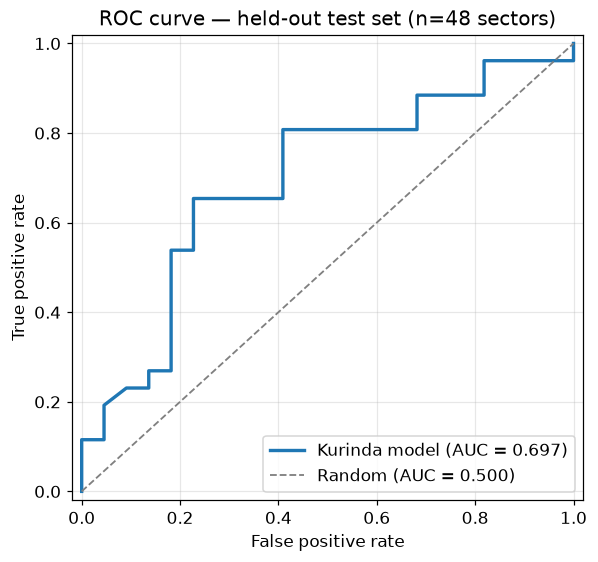

In [24]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(fpr, tpr, color="#1f77b4", lw=2.2,
        label=f"Kurinda model (AUC = {test_auc:.3f})")
ax.plot([0, 1], [0, 1], color="grey", lw=1.2, ls="--", label="Random (AUC = 0.500)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve — held-out test set (n=48 sectors)")
ax.legend(loc="lower right", frameon=True)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
save_fig(fig, "roc_curve.png")
plt.show()


### 11.2 Confusion matrix (test set, threshold 0.5)

  saved: C:\Users\Hello\kurinda\ml\notebooks\figures\03_model_training\confusion_matrix.png


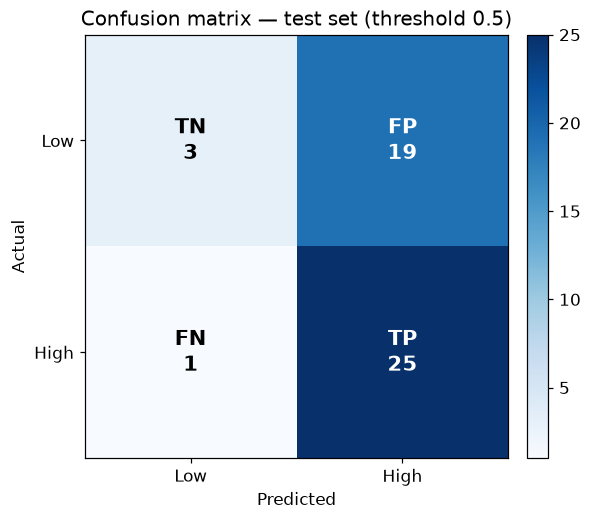

In [25]:
import numpy as np

cm_plot = confusion_matrix(y_test, y_test_pred)   # [[TN, FP], [FN, TP]]

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm_plot, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Low", "High"]); ax.set_yticklabels(["Low", "High"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion matrix — test set (threshold 0.5)")
ax.grid(False)

labels = [["TN", "FP"], ["FN", "TP"]]
for r in range(2):
    for c in range(2):
        val = cm_plot[r, c]
        color = "white" if val > cm_plot.max() / 2 else "black"
        ax.text(c, r, f"{labels[r][c]}\n{val}", ha="center", va="center",
                color=color, fontsize=14, fontweight="bold")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
save_fig(fig, "confusion_matrix.png")
plt.show()


### 11.3 Precision / recall vs decision threshold

  saved: C:\Users\Hello\kurinda\ml\notebooks\figures\03_model_training\threshold_sweep.png


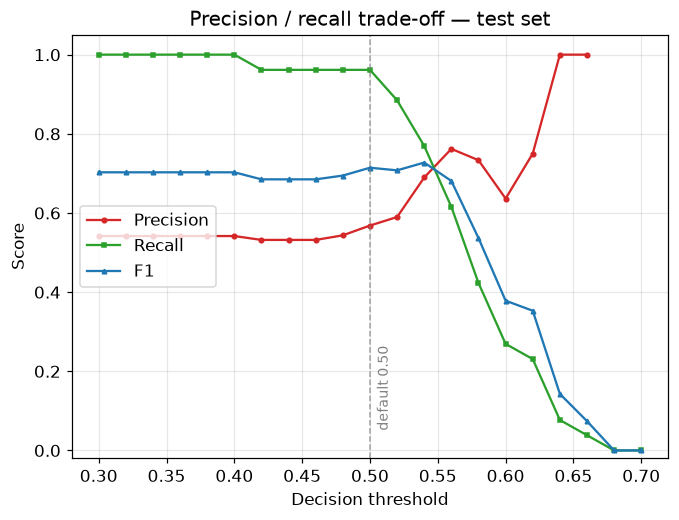

In [26]:
thresholds = np.arange(0.30, 0.72, 0.02)
prec, rec, f1s = [], [], []
for t in thresholds:
    yp = (y_test_proba >= t).astype(int)
    if yp.sum() == 0:
        prec.append(np.nan); rec.append(0.0); f1s.append(0.0); continue
    prec.append(precision_score(y_test, yp, zero_division=0))
    rec.append(recall_score(y_test, yp, zero_division=0))
    f1s.append(f1_score(y_test, yp, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thresholds, prec, marker="o", ms=3, label="Precision", color="#d62728")
ax.plot(thresholds, rec,  marker="s", ms=3, label="Recall",    color="#2ca02c")
ax.plot(thresholds, f1s,  marker="^", ms=3, label="F1",        color="#1f77b4")
ax.axvline(0.50, color="grey", ls="--", lw=1, alpha=0.7)
ax.text(0.505, 0.05, "default 0.50", rotation=90, va="bottom", fontsize=9, color="grey")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / recall trade-off — test set")
ax.legend(loc="center left")
ax.set_ylim(-0.02, 1.05)
save_fig(fig, "threshold_sweep.png")
plt.show()


### 11.4 SHAP summary (beeswarm) — test set

The single most important explainability figure: shows which features
drive predictions and in which direction. `shap_test` is already the
positive-class SHAP array from Cell 31.


C:\Users\Hello\AppData\Local\Temp\ipykernel_17336\895883895.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


  saved: C:\Users\Hello\kurinda\ml\notebooks\figures\03_model_training\shap_summary.png


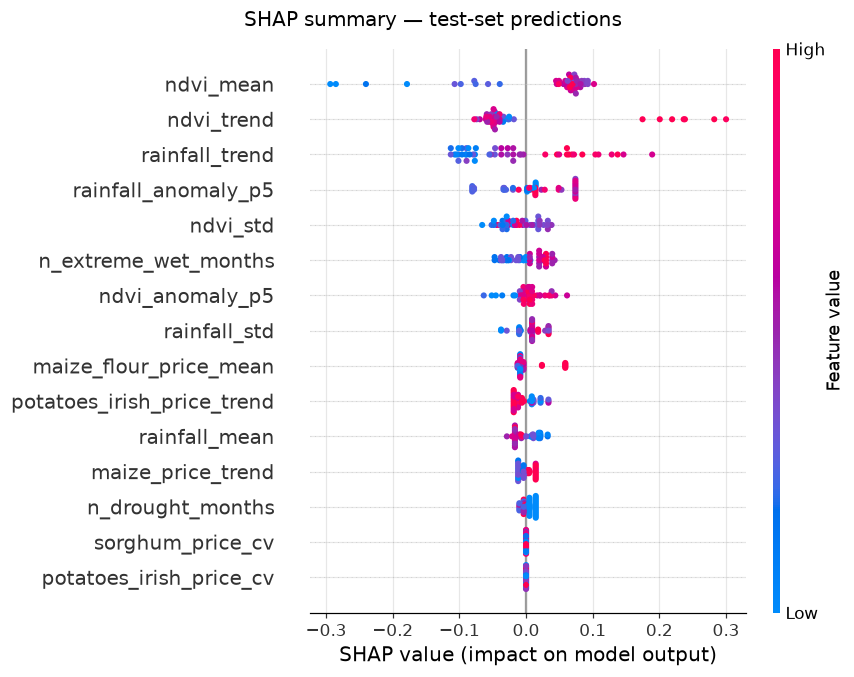

In [27]:
import shap

# shap.summary_plot draws onto the current matplotlib figure
fig = plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_test, X_test,
    feature_names=surviving_features,
    show=False, max_display=15, plot_size=None,
)
fig = plt.gcf()
fig.suptitle("SHAP summary — test-set predictions", fontsize=13, y=1.02)
save_fig(fig, "shap_summary.png")
plt.show()


### 11.5 Leave-one-province-out AUC by province

  saved: C:\Users\Hello\kurinda\ml\notebooks\figures\03_model_training\lopo_by_province.png


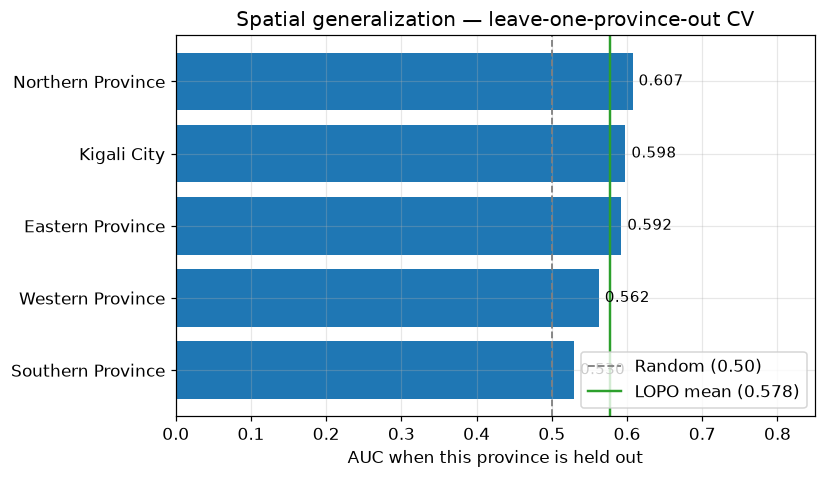

In [28]:
lopo_sorted = lopo_df.sort_values("auc", ascending=True)
mean_auc = lopo_df["auc"].mean()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = ["#d62728" if a < 0.5 else "#1f77b4" for a in lopo_sorted["auc"]]
bars = ax.barh(lopo_sorted["province"], lopo_sorted["auc"], color=colors)
ax.axvline(0.5, color="grey", ls="--", lw=1.2, label="Random (0.50)")
ax.axvline(mean_auc, color="#2ca02c", ls="-", lw=1.6, label=f"LOPO mean ({mean_auc:.3f})")
for bar, a in zip(bars, lopo_sorted["auc"]):
    ax.text(a + 0.008, bar.get_y() + bar.get_height()/2, f"{a:.3f}",
            va="center", fontsize=10)
ax.set_xlabel("AUC when this province is held out")
ax.set_title("Spatial generalization — leave-one-province-out CV")
ax.set_xlim(0, 0.85)
ax.legend(loc="lower right")
save_fig(fig, "lopo_by_province.png")
plt.show()


### 11.6 LightGBM feature importance (gain)

  saved: C:\Users\Hello\kurinda\ml\notebooks\figures\03_model_training\feature_importance.png


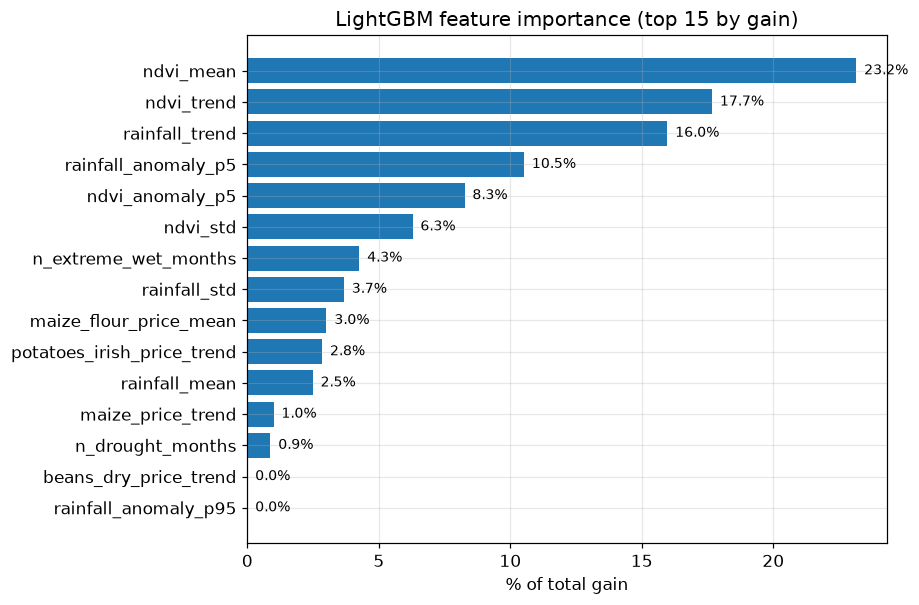


All six figures saved to figures/03_model_training/


In [29]:
top_imp = importance_df.head(15).sort_values("gain_pct", ascending=True)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.barh(top_imp["feature"], top_imp["gain_pct"], color="#1f77b4")
ax.set_xlabel("% of total gain")
ax.set_title("LightGBM feature importance (top 15 by gain)")
for y, v in enumerate(top_imp["gain_pct"]):
    ax.text(v + 0.3, y, f"{v:.1f}%", va="center", fontsize=9)
save_fig(fig, "feature_importance.png")
plt.show()

print("\nAll six figures saved to figures/03_model_training/")


## 12. Export sector GeoJSON for the dashboard map

Joins the 422-sector risk file (`sectors_for_dashboard.csv`) to the GADM
sector polygons and writes `sectors_risk.geojson` — the single artifact the
Next.js/Leaflet map consumes. Output goes to `data/processed/` (tracked),
not `data/raw/` (git-ignored). The join is validated: if any sector's GID_3
fails to match a polygon, the cell stops rather than produce a map with gaps.


In [30]:
import geopandas as gpd

# Paths (relative to ml/notebooks/)
GADM_GPKG     = Path("../../data/raw/geo/gadm41_RWA.gpkg")
DASHBOARD_CSV = MODEL_DIR / "sectors_for_dashboard.csv"
GEOJSON_OUT   = MODEL_DIR / "sectors_risk.geojson"

# 1. Load sector polygons (same layer/columns Notebook 02 used for the spatial join)
gdf = gpd.read_file(GADM_GPKG, layer="ADM_ADM_3")[
    ["GID_3", "NAME_3", "NAME_2", "NAME_1", "geometry"]
]
print(f"GADM sectors loaded: {len(gdf)}  (CRS {gdf.crs})")

# 2. Dissolve any multipart GID_3 into one geometry per sector
n_before = len(gdf)
gdf = gdf.dissolve(by="GID_3", as_index=False, aggfunc="first")
if n_before != len(gdf):
    print(f"Dissolved {n_before - len(gdf)} multipart row(s) -> {len(gdf)} unique sectors")

# 3. Ensure WGS84 (EPSG:4326) — what Leaflet expects
if gdf.crs is None or gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(epsg=4326)

# 4. Load the risk file and join on GID_3 (drop name cols the polygon layer already has)
risk = pd.read_csv(DASHBOARD_CSV)
merged = gdf.merge(
    risk.drop(columns=["sector", "district", "province"]),
    on="GID_3", how="left",
)

# 5. Validate — every sector must carry a risk value, or the map has holes
n_total    = len(merged)
n_with_risk = int(merged["risk_value"].notna().sum())
print(f"Join result: {n_total} polygons, {n_with_risk} with risk values")
assert n_total == 422, f"Expected 422 sectors, got {n_total}"
assert n_with_risk == 422, (
    f"{n_total - n_with_risk} sector(s) have no risk value — GID_3 mismatch. "
    f"Fix before shipping the map."
)

# 6. Trim precision (smaller payload) and write GeoJSON
merged["risk_value"] = merged["risk_value"].round(4)
merged.to_file(GEOJSON_OUT, driver="GeoJSON")

kb = GEOJSON_OUT.stat().st_size / 1024
print(f"\nWrote {GEOJSON_OUT.name}: {n_total} features, {kb:.0f} KB")
print(f"  path: {GEOJSON_OUT.resolve()}")
print(f"\nProperties per feature: "
      f"{[c for c in merged.columns if c != 'geometry']}")
print(f"\nSource breakdown in map:")
print(merged["source"].value_counts().to_string())


GADM sectors loaded: 422  (CRS EPSG:4326)
Join result: 422 polygons, 422 with risk values

Wrote sectors_risk.geojson: 422 features, 26224 KB
  path: C:\Users\Hello\kurinda\data\processed\model\sectors_risk.geojson

Properties per feature: ['GID_3', 'NAME_3', 'NAME_2', 'NAME_1', 'province_en', 'risk_value', 'is_high_risk', 'source', 'confidence_band', 'risk_driver_1', 'risk_driver_2', 'risk_driver_3', 'protective_factor']

Source breakdown in map:
source
dhs_measurement_2019_20    320
model_prediction           102
